In [1]:
# !pip install scikit-optimize
# from google.colab import drive
# drive.mount('/content/drive')
# base_dir='/content/drive/MyDrive/ucd/'
base_dir='../../../folders/'

In [2]:
import pandas as pd
import numpy as np
import pickle
# from sklearnex import patch_sklearn
# patch_sklearn()
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition, datasets
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from collections import Counter
from sklearn.preprocessing import LabelEncoder
# from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
np.int = np.int_
import warnings
warnings.filterwarnings("ignore")

c:\Users\zazaz\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
data_base=[f'ucddb{i:003d}' for i in range(2, 29)]
data_base.remove('ucddb004')
data_base.remove('ucddb016')
print(data_base)

['ucddb002', 'ucddb003', 'ucddb005', 'ucddb006', 'ucddb007', 'ucddb008', 'ucddb009', 'ucddb010', 'ucddb011', 'ucddb012', 'ucddb013', 'ucddb014', 'ucddb015', 'ucddb017', 'ucddb018', 'ucddb019', 'ucddb020', 'ucddb021', 'ucddb022', 'ucddb023', 'ucddb024', 'ucddb025', 'ucddb026', 'ucddb027', 'ucddb028']


In [4]:
df = pd.DataFrame()
for file in data_base:
    i=pd.read_csv(base_dir+f'feature/{file}_win.csv')
    df = pd.concat([df, i], ignore_index=True)
df.dropna(how='all', axis=1,inplace=True)
df.to_csv(base_dir+f'feature/all.csv', index=False)
del df

In [5]:
data_set = pd.read_csv(base_dir+f'feature/all.csv')
data_set = data_set.replace((np.inf, -np.inf, np.nan), 0).reset_index(drop=True)
data_set

,HRV_MeanNN_x,HRV_SDNN_x,HRV_RMSSD_x,HRV_SDSD_x,HRV_CVNN_x,HRV_CVSD_x,HRV_MedianNN_x,HRV_MadNN_x,HRV_MCVNN_x,HRV_IQRNN_x,...,peak_to_peak_y,rmse_y,kurtosis_y,skewness_y,waveform_factor_y,peak_factor_y,impulse_factor_y,margin_factor_y,rms_y,anns
0,941.406250,13.877191,10.461470,10.590011,0.014741,0.011113,937.50000,11.582812,0.012355,23.437500,...,4.139683,0.544480,11.053443,-1.902077,0.240205,7.603004,1.826277,3.375959,2.329211,0
1,932.963710,19.740977,10.578175,10.598053,0.021159,0.011338,937.50000,11.582812,0.012355,15.625000,...,4.139683,0.575854,9.884734,-1.935100,0.247783,7.188769,1.781256,3.355983,2.390519,0
2,784.417230,84.031488,92.695165,94.005934,0.107126,0.118171,773.43750,57.914062,0.074879,93.750000,...,4.139683,0.580730,9.461187,-2.035756,0.242450,7.128412,1.728284,3.331284,2.463838,0
3,915.826613,27.783640,20.768127,21.063296,0.030337,0.022677,914.06250,23.165625,0.025344,27.343750,...,4.122100,0.519223,9.321251,-1.714604,0.208773,7.938973,1.657443,3.286943,2.537061,0
4,851.562500,115.654429,69.943265,71.024059,0.135814,0.082135,878.90625,98.453906,0.112019,146.484375,...,4.122100,0.529632,11.237479,-2.104502,0.207341,7.782954,1.613729,3.264630,2.601584,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20425,803.819444,42.248541,22.410536,22.369303,0.052560,0.027880,808.59375,28.957031,0.035812,33.203125,...,0.209035,0.093495,-1.386944,-0.197173,0.030050,2.235788,0.067186,0.157397,3.112016,0
20426,740.985577,57.787447,17.377094,17.605423,0.077987,0.023451,734.37500,69.496875,0.094634,85.937500,...,0.209035,0.094201,-1.390740,-0.209118,0.030278,2.219033,0.067188,0.157398,3.111909,0
20427,805.555556,13.043136,11.587810,11.754803,0.016191,0.014385,804.68750,11.582812,0.014394,15.625000,...,0.205128,0.091285,-1.388441,-0.226654,0.029323,2.247114,0.065892,0.154433,3.113800,0
20428,808.159722,16.004808,10.889563,11.048543,0.019804,0.013475,812.50000,23.165625,0.028512,23.437500,...,0.207082,0.092272,-1.376514,-0.198010,0.029651,2.244253,0.066544,0.155918,3.112656,2


In [6]:
# Assuming your target variable is named 'target'
x = data_set.drop('anns', axis=1)  # Features
y = data_set['anns']  # Target variable

# Create the estimator (in this case, LogisticRegression)
estimator = RandomForestClassifier(verbose=1,n_jobs=20)

# Create the RFE object
rfe = RFE(estimator, n_features_to_select=30, step=3, verbose=10)

# Fit the RFE object to the data
rfe.fit(x, y)

# Get the column names of the selected features
selected_features = x.columns[rfe.support_]

# Create a new DataFrame with the selected features
x = data_set[selected_features]

Fitting estimator with 187 features.


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    3.7s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.


Fitting estimator with 184 features.


[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    3.9s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.


Fitting estimator with 181 features.


...

[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.6s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.8s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.


Fitting estimator with 34 features.


[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.


Fitting estimator with 31 features.


[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.5s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.2s finished


In [7]:
x

,HRV_MeanNN_x,HRV_Prc20NN_x,HRV_MeanNN_y,HRV_SDANN1_y,HRV_CVSD_y,HRV_MCVNN_y,HRV_SDRMSSD_y,HRV_Prc80NN_y,HRV_pNN20_y,HRV_MinNN_y,...,max_y,mean_y,var_y,rmse_y,skewness_y,waveform_factor_y,peak_factor_y,impulse_factor_y,margin_factor_y,rms_y
0,941.406250,929.6875,887.054896,55.045392,0.111944,0.062822,1.180125,953.1250,32.937685,304.6875,...,3.170696,2.266733,0.287144,0.544480,-1.902077,0.240205,7.603004,1.826277,3.375959,2.329211
1,932.963710,929.6875,890.181903,34.516891,0.112334,0.062822,1.181979,968.7500,35.223881,304.6875,...,3.170696,2.324025,0.313492,0.575854,-1.935100,0.247783,7.188769,1.781256,3.355983,2.390519
2,784.417230,750.0000,893.314933,59.306612,0.112102,0.062294,1.197097,968.7500,35.928144,304.6875,...,3.170696,2.395256,0.333247,0.580730,-2.035756,0.242450,7.128412,1.728284,3.331284,2.463838
3,915.826613,898.4375,911.847370,38.943009,0.105690,0.049420,1.165251,976.5625,32.926829,304.6875,...,3.153114,2.487024,0.251389,0.519223,-1.714604,0.208773,7.938973,1.657443,3.286943,2.537061
4,851.562500,789.0625,913.560780,54.877815,0.105679,0.036759,1.168852,976.5625,32.110092,304.6875,...,3.153114,2.554394,0.243308,0.529632,-2.104502,0.207341,7.782954,1.613729,3.264630,2.601584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20425,803.819444,789.0625,793.849469,14.224312,0.020415,0.029071,2.215166,820.3125,12.466844,632.8125,...,3.207814,3.111308,0.004410,0.093495,-0.197173,0.030050,2.235788,0.067186,0.157397,3.112016
20426,740.985577,692.1875,794.921875,16.700587,0.019212,0.028788,2.249370,820.3125,12.500000,632.8125,...,3.207814,3.111202,0.004402,0.094201,-0.209118,0.030278,2.219033,0.067188,0.157398,3.111909
20427,805.555556,796.8750,800.289042,6.541426,0.018375,0.028788,1.571215,820.3125,10.723861,726.5625,...,3.203907,3.113112,0.004285,0.091285,-0.226654,0.029323,2.247114,0.065892,0.154433,3.113800
20428,808.159722,796.8750,793.662964,18.535262,0.018353,0.029071,2.075336,820.3125,10.344828,679.6875,...,3.203907,3.111969,0.004276,0.092272,-0.198010,0.029651,2.244253,0.066544,0.155918,3.112656


In [8]:
print(selected_features)

Index(['HRV_MeanNN_x', 'HRV_Prc20NN_x', 'HRV_MeanNN_y', 'HRV_SDANN1_y',
       'HRV_CVSD_y', 'HRV_MCVNN_y', 'HRV_SDRMSSD_y', 'HRV_Prc80NN_y',
       'HRV_pNN20_y', 'HRV_MinNN_y', 'HRV_MaxNN_y', 'HRV_CSI_Modified_y',
       'HRV_IALS_y', 'HRV_PSS_y', 'HRV_PI_y', 'HRV_DFA_alpha1_y',
       'HRV_ShanEn_y', 'HRV_FuzzyEn_y', 'HRV_CD_y', 'HRV_HFD_y', 'max_y',
       'mean_y', 'var_y', 'rmse_y', 'skewness_y', 'waveform_factor_y',
       'peak_factor_y', 'impulse_factor_y', 'margin_factor_y', 'rms_y'],
      dtype='object')


Class=0, n=4416 (21.615%)
Class=2, n=10347 (50.646%)
Class=3, n=2676 (13.098%)
Class=1, n=2991 (14.640%)


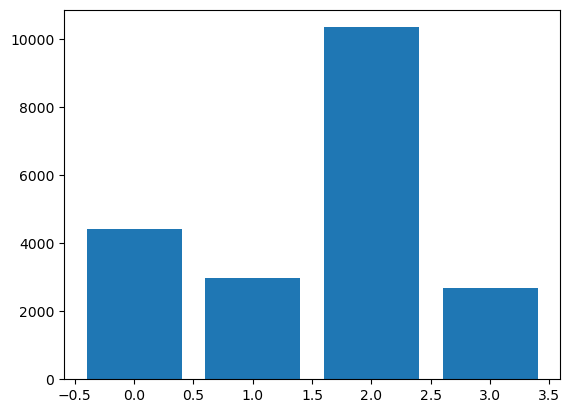

In [9]:
# summarize distribution
counter = Counter(y)
for k,v in counter.items():
 per = v / len(y) * 100
 print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the distribution
plt.bar(counter.keys(), counter.values())
plt.show()

In [10]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2,stratify=y,random_state=1)

In [11]:
print(x_test.shape)
print(y_test.shape)
result = {'x_test':x_test, 'y_test':y_test}
del x_test
del y_test
with open(base_dir+'feature/test_all.pkl', 'wb') as f:
    pickle.dump(result, f)
del result  

(4086, 30)
(4086,)


In [12]:
print(x_train.shape)
print(y_train.shape)
result = {'x_train':x_train, 'y_train':y_train}
del x_train
del y_train
with open(base_dir+'feature/train_all.pkl', 'wb') as f:
    pickle.dump(result, f)
del result 

(16344, 30)
(16344,)
